In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"]=(10,6)

In [3]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

processed = BASE_DIR / "data" / "processed"
raw = BASE_DIR / "data" / "raw"

nav = pd.read_csv(processed/"nav_history_cleaned.csv")
trans = pd.read_csv(processed/"investor_transactions_cleaned.csv")
perf = pd.read_csv(processed/"scheme_performance_cleaned.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
trans["transaction_date"] = pd.to_datetime(trans["transaction_date"])

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
trans.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [8]:
perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [10]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend"
)

fig.show()

In [12]:
fig.write_image("../reports/nav_trend.png")

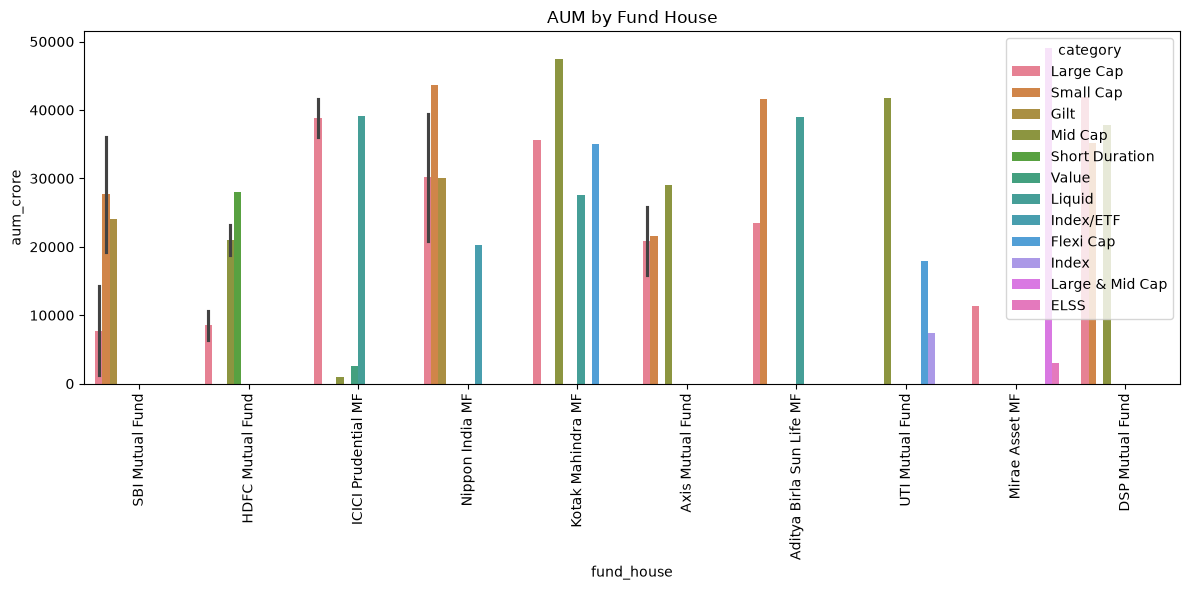

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=perf,
    x="fund_house",
    y="aum_crore",
    hue="category"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.tight_layout()

plt.savefig("../reports/aum_growth.png")
plt.show()

In [15]:
trans["transaction_date"] = pd.to_datetime(trans["transaction_date"])

sip = trans[trans["transaction_type"]=="SIP"]

monthly = sip.groupby(
    sip["transaction_date"].dt.to_period("M")
)["amount_inr"].sum().reset_index()

monthly["transaction_date"] = monthly["transaction_date"].astype(str)

fig = px.line(
    monthly,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow"
)

fig.show()

In [16]:
fig.write_image("../reports/sip_inflow.png")

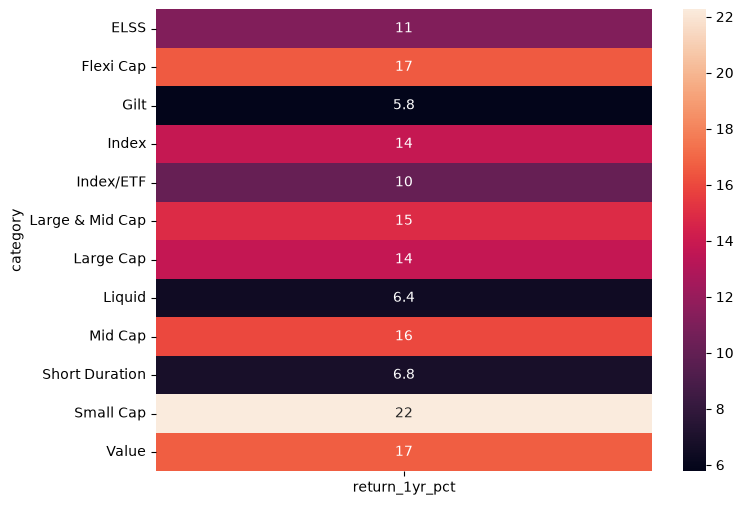

In [18]:
heat = perf.pivot_table(
    index="category",
    values="return_1yr_pct",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True)

plt.savefig("../reports/category_heatmap.png")
plt.show()

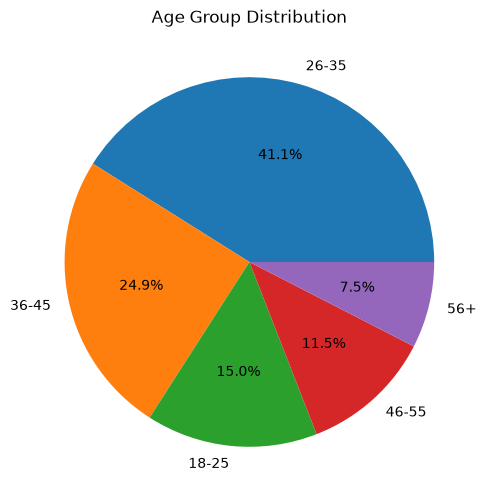

In [20]:
trans["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.savefig("../reports/age_pie.png")
plt.show()

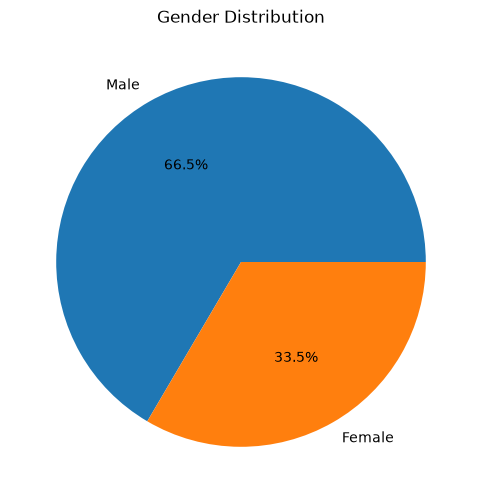

In [22]:
trans["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.savefig("../reports/gender_pie.png")
plt.show()

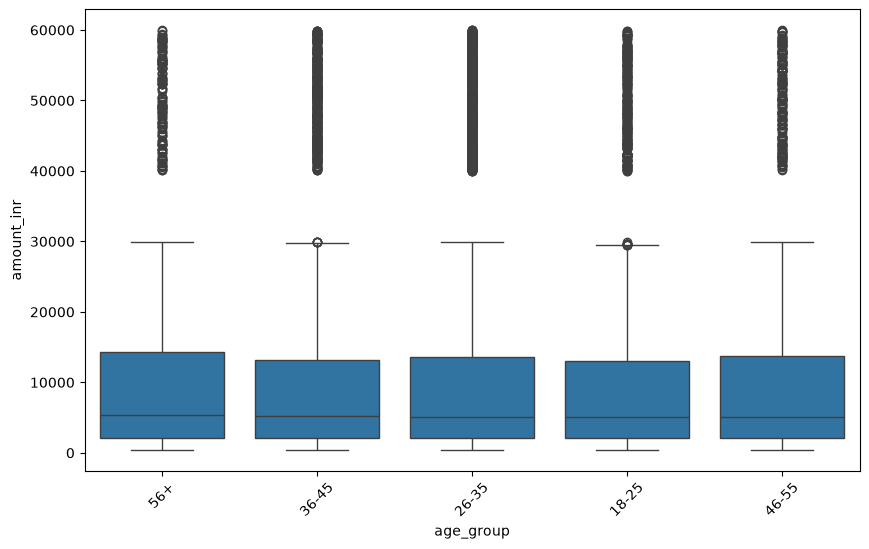

In [24]:
sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)
plt.savefig("../reports/sip_boxplot.png")
plt.show()

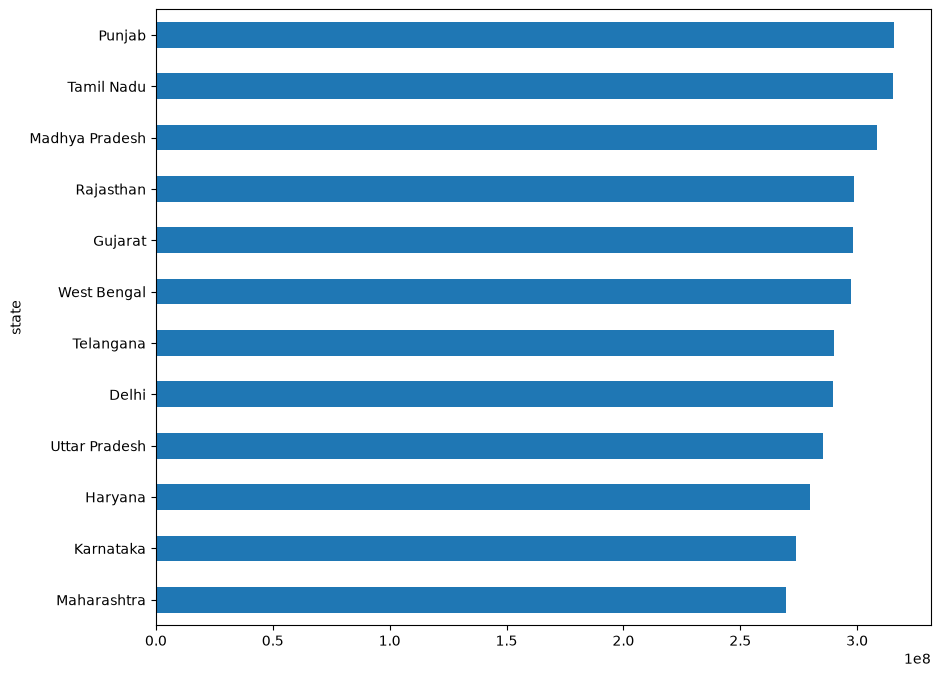

In [25]:
state = trans.groupby("state")["amount_inr"].sum()

state.sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.savefig("../reports/state_bar.png")
plt.show()

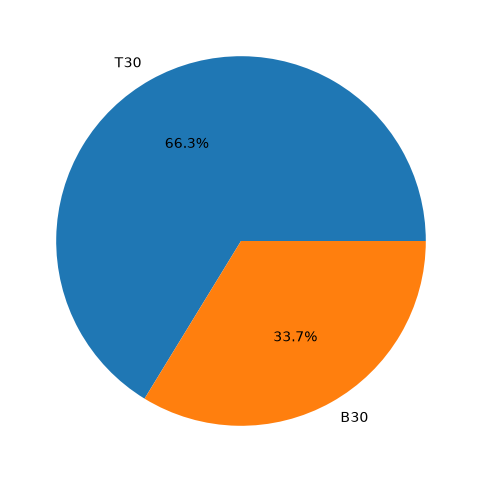

In [26]:
trans["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.savefig("../reports/city_tier.png")
plt.show()

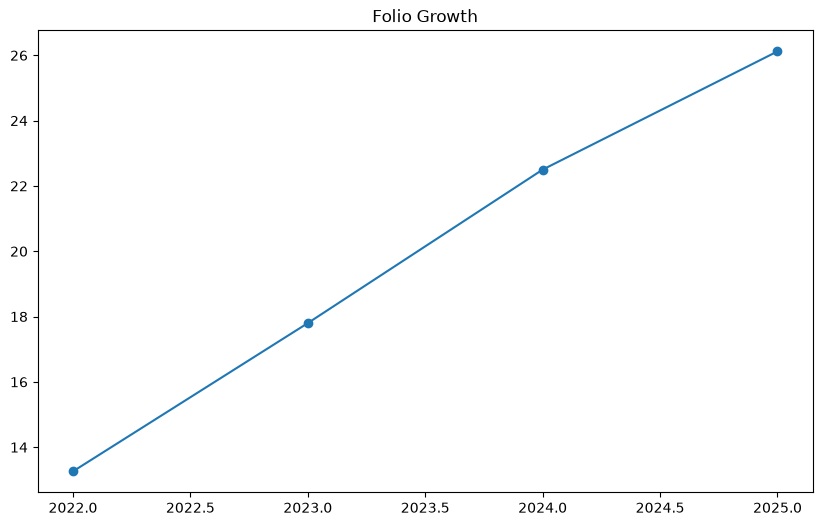

In [27]:
years=[2022,2023,2024,2025]

folios=[13.26,17.8,22.5,26.12]

plt.plot(years,folios,marker="o")

plt.title("Folio Growth")

plt.savefig("../reports/folio_growth.png")

plt.show()

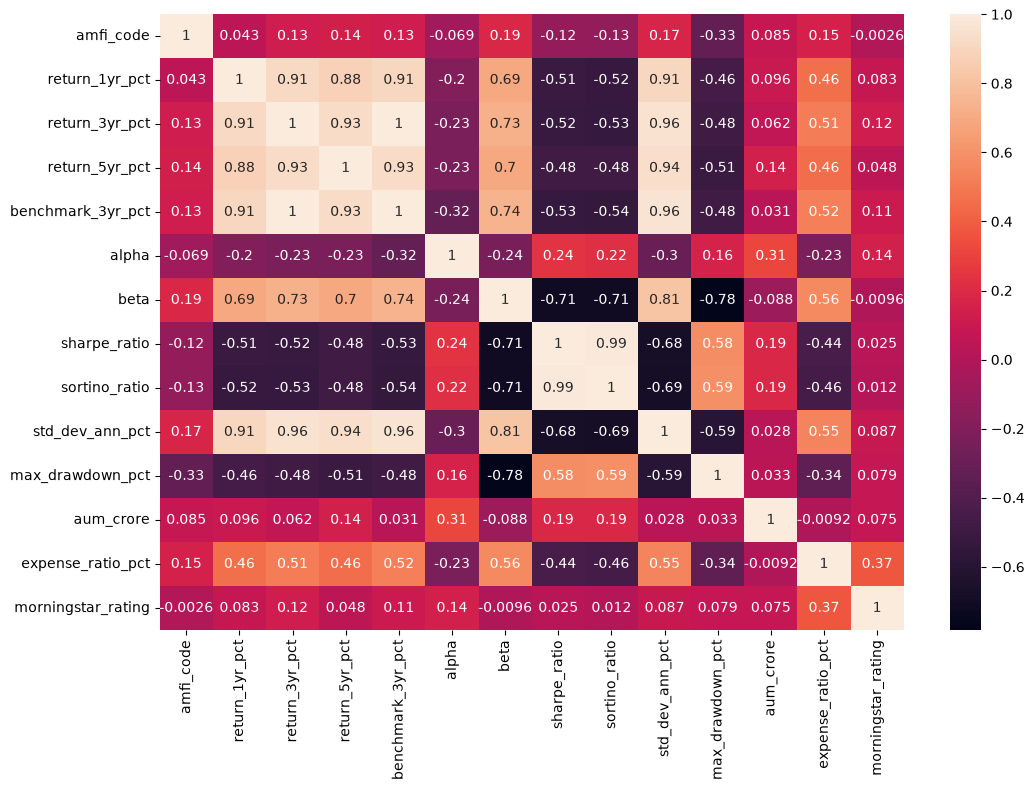

In [28]:
corr = perf.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr,annot=True)

plt.savefig("../reports/correlation.png")

plt.show()

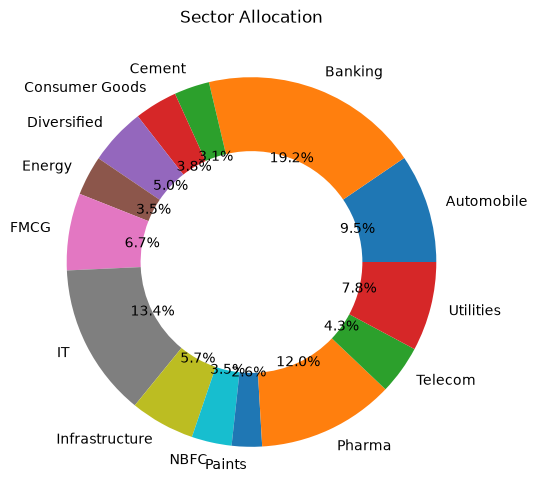

In [30]:
hold = pd.read_csv(raw/"09_portfolio_holdings.csv")

sector = hold.groupby("sector")["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.savefig("../reports/sector_donut.png")

plt.show()

## Insight 1
Daily NAV generally increased from 2022 to 2026 with temporary market corrections during 2024.

## Insight 2
SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses.

## Insight 3
Monthly SIP inflows showed a consistent upward trend and reached their highest value in December 2025.

## Insight 4
Large Cap and Flexi Cap categories attracted higher inflows compared to most other categories.

## Insight 5
The 26–35 age group contributed the highest number of mutual fund investments.

## Insight 6
SIP investment amounts varied across age groups, with working professionals investing larger amounts.

## Insight 7
Tier-30 cities contributed a larger share of investments than Beyond-30 (B30) cities.

## Insight 8
Folio counts increased steadily from 2022 to 2025, indicating strong growth in retail participation.

## Insight 9
Several equity funds showed a strong positive correlation in daily NAV returns.

## Insight 10
Financial Services and Information Technology formed a major portion of the overall portfolio allocation.